In [1]:
# GROUP 2 CODE
# Members: Amiri, Ebru, Madison, Cailyn
# Github: https://github.com/AmiriHayes/rockphysicsproject

"""
Goals: 
- Develop simulated 3D data to work with [✓]
- Simplify dataset (into graph network) [✓]
- Predict fluid flow on simulated data [✓]

To install, run "pip install -r requirements.txt" in terminal 
Then ensure you use "pip install git+https://github.com/PMEAL/porespy.git@dev" to install latest porespy!

Code References:
1. polydisperse_spheres: https://porespy.org/examples/generators/reference/polydisperse_spheres.html
2. open_pnm_to_im: https://porespy.org/modules/generated/generated/porespy.io.openpnm_to_im.html
3. predict fluid flow: https://openpnm.org/examples/applications/network_extraction.html

"""

'\nGoals: \n- Develop simulated 3D data to work with [✓]\n- Simplify dataset (into graph network) [✓]\n- Predict fluid flow on simulated data [✓]\n\nTo install, run "pip install -r requirements.txt" in terminal \nThen ensure you use "pip install git+https://github.com/PMEAL/porespy.git@dev" to install latest porespy!\n\nCode References:\n1. polydisperse_spheres: https://porespy.org/examples/generators/reference/polydisperse_spheres.html\n2. open_pnm_to_im: https://porespy.org/modules/generated/generated/porespy.io.openpnm_to_im.html\n3. predict fluid flow: https://openpnm.org/examples/applications/network_extraction.html\n\n'

In [15]:
# imports:

import numpy as np
print(np.__version__)
import porespy as ps
import openpnm as op
import matplotlib.pyplot as plt
from tqdm import tqdm
ps.visualization.set_mpl_style()
np.random.seed(10)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Extracting pore and throat properties:   0%|          | 0/7436 [00:00<?, ?it/s]

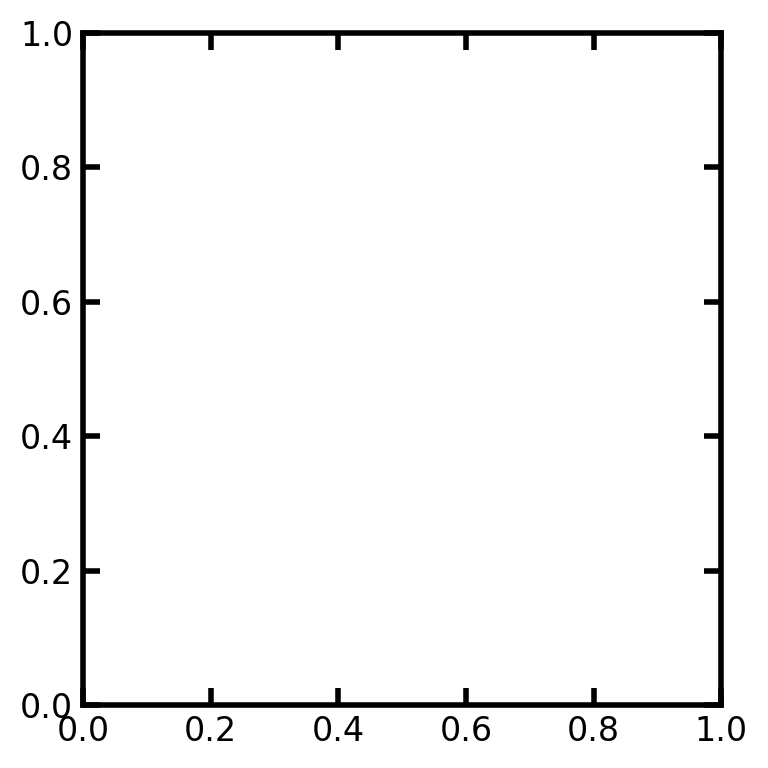

In [24]:
# pore-reduction:

im = ps.generators.blobs(shape=[400, 400, 400], porosity=0.6, blobiness=2)
# fig, ax = plt.subplots(figsize=(4, 4))
# ax.imshow(im)

snow_output = ps.networks.snow2(im, voxel_size=1)

In [31]:
# convert to openim graph network:

pn = op.io.network_from_porespy(snow_output.network)

# fig, ax = plt.subplots(figsize=[5, 5])
# ax.imshow(im.T, cmap=plt.cm.bone)
# op.visualization.plot_coordinates(ax=fig,
#                                   network=pn,
#                                   size_by=pn["pore.inscribed_diameter"],
#                                   color_by=pn["pore.inscribed_diameter"],
#                                   markersize=200)
# op.visualization.plot_connections(network=pn, ax=fig)
# ax.axis("off")

In [32]:
data = {
    'shape': {
        'x': im.shape[0],
        'y': im.shape[1],
        'z': im.shape[2],
    },
    'resolution': 5.345e-6,
    'porosity': 19.6,
    'permeability': {
        'Kx': 1360,
        'Ky': 1304,
        'Kz': 1193,
        'Kave': 1286,
    },
    'formation factor': {
        'Fx': 23.12,
        'Fy': 23.99,
        'Fz': 25.22,
        'Fave': 24.08,
    },
}

In [56]:
# define network statististics

pn['pore.diameter'] = pn['pore.equivalent_diameter']
pn['throat.diameter'] = pn['throat.inscribed_diameter']
pn['throat.spacing'] = pn['throat.total_length']

pn.add_model(propname='throat.hydraulic_size_factors',
             model=op.models.geometry.hydraulic_size_factors.pyramids_and_cuboids)
pn.add_model(propname='throat.diffusive_size_factors',
             model=op.models.geometry.diffusive_size_factors.pyramids_and_cuboids)

pn['throat.hydraulic_conductance'] = pn['throat.diameter'] / pn['throat.spacing']

pn.regenerate_models()

[13:54:39] WARNING  throat.hydraulic_conductance was not run since the following property is         ]8;id=898946;file:///Users/ebrushka/anaconda3/lib/python3.11/site-packages/openpnm/core/_models.py\_models.py]8;;\:]8;id=715810;file:///Users/ebrushka/anaconda3/lib/python3.11/site-packages/openpnm/core/_models.py#480\480]8;;\
                    missing: 'pore.viscosity'                                                                      

In [57]:
# check network is valid

h = op.utils.check_network_health(pn)
print(h)

op.topotools.trim(network=pn, pores=h['disconnected_pores'])
h = op.utils.check_network_health(pn)
print(h)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
―――――――――――――――――――――――――――――――――――――――――――――――――――――

In [64]:
# define necessary gas / liquid properties and physics models 

gas = op.phase.Phase(network=pn)
gas['pore.diffusivity'] = 1.0
gas['pore.viscosity'] = 1.0
gas['throat.entry_pressure'] = 0
gas['throat.surface_tension'] = 1.0


gas.add_model(propname="pore.viscosity", model=op.models.misc.constant, value=1.0)
gas.add_model(propname="pore.diffusivity", model=op.models.misc.constant, value=1.0)
gas.add_model(
    propname="throat.diffusive_conductance",
    model=op.models.misc.constant, value=1.0
)

In [65]:
# calculate the flow through simulated dataset

fd = op.algorithms.FickianDiffusion(network=pn, phase=gas)
fd.set_value_BC(pores=pn.pores('xmin'), values=1.0)
fd.set_value_BC(pores=pn.pores('xmax'), values=0.0)
fd.run()

dC = 1.0
L = (data['shape']['x'] + 6) * data['resolution']
A = data['shape']['y'] * data['shape']['z'] * data['resolution']**2
Deff = fd.rate(pores=pn.pores('xmin')) * (L / A) / dC
F = 1 / Deff

print(f"The Formation factor of the extracted network is {F[0]}")
print(f"This compares to a value of {data['formation factor']['Fx']} from DNS")
# np.testing.assert_allclose(F, data['formation factor']['Fx'], rtol=0.09)

The Formation factor of the extracted network is 9.663845848774733e-05
This compares to a value of 23.12 from DNS


In [66]:
sf = op.algorithms.StokesFlow(network=pn, phase=gas)
sf.set_value_BC(pores=pn.pores('xmin'), values=1.0)
sf.set_value_BC(pores=pn.pores('xmax'), values=0.0)
sf.run()
dP = 1.0
L = (data['shape']['x'] + 6)*data['resolution']
A = data['shape']['y']*data['shape']['z']*data['resolution']**2
K = sf.rate(pores=pn.pores('xmin'))*(L/A)/dP*1e12
print(f'Permeability coefficient is {K[0]} Darcy')
print(f"The compares to a value of {data['permeability']['Kx']/1000} from DNS")

Permeability coefficient is 4386551922124995.0 Darcy
The compares to a value of 1.36 from DNS
